In [1]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os

In [31]:
import json
from pprint import pprint

path = r'jobs\20251022_171601\exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h512-256-128'
path = r'jobs\20251110_122808\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'

metrics_path = path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

pprint(metrics_data.keys())

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])


In [32]:
metrics_data['dataset_meta']

{'environment_config': {'num_modes': 25,
  'pixel_resolution': 64,
  'oversizing_factor': 1,
  'num_airy': 5,
  'coronagraph_charge': 6,
  'ppsr': 2},
 'dataset_config': {'N': 100000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'num_samples': 100000,
 'image_triplet_description': '(baseline, +nudge, -nudge)'}

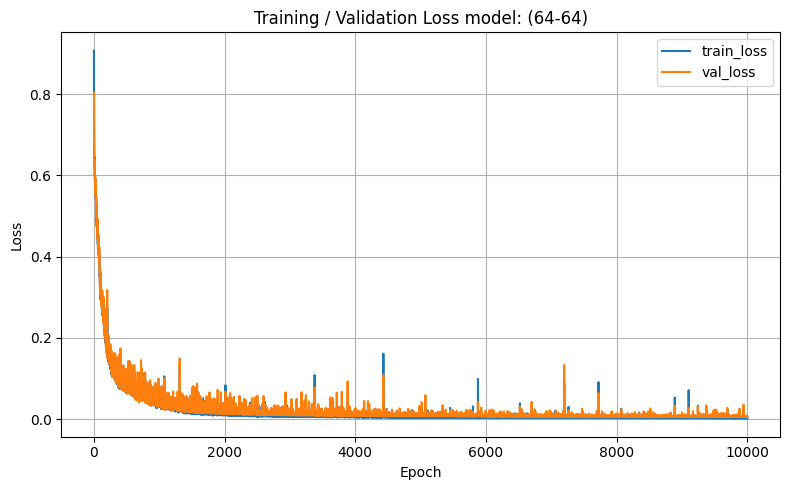

In [33]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss model: (64-64)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(path, '*.pth')) + glob.glob(os.path.join(path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)


In [35]:
metrics_data['y_norm']

{'mean': -2.08677190111084e-11, 'std': 1.9999989220309544e-08}

In [36]:
metrics_data.keys()

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])

In [38]:
metrics_data['dataset_meta']

{'environment_config': {'num_modes': 25,
  'pixel_resolution': 64,
  'oversizing_factor': 1,
  'num_airy': 5,
  'coronagraph_charge': 6,
  'ppsr': 2},
 'dataset_config': {'N': 100000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'num_samples': 100000,
 'image_triplet_description': '(baseline, +nudge, -nudge)'}

In [24]:
metrics_data['input_shape']

[20, 20, 3]

In [28]:
from archs.fc1 import FC1
import torch

model = FC1(
    final_output_dim=metrics_data['output_dim'], 
    image_input_shape=metrics_data['input_shape'], 
    hidden_layers=metrics_data['args']['fc1_hidden'], 
    activation=metrics_data['args']['fc1_activation'],
    final_activation=metrics_data['args']['fc1_final_activation']    
    )
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1200, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=128, out_features=25, bias=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
)

In [ ]:
from environment import CoronagraphEnvironment

env_config = metrics_data['dataset_meta']['environment_config']
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')

env = CoronagraphEnvironment(**env_config)

{'num_modes': 25, 'oversizing_factor': 1, 'num_airy': 5, 'coronagraph_charge': 6, 'pixels': 64, 'pixels_per_spacial_res': 2}
initializing coronagraph env. might take a minute.


In [17]:
import pickle
from pathlib import Path

dataset_path = Path(r'data\dataset100S25M.pkl')
if not dataset_path.exists():
    raise FileNotFoundError(f"{dataset_path} not found")

with dataset_path.open('rb') as f:
    dataset = pickle.load(f)

print("Loaded:", dataset_path)
print("Type:", type(dataset))

if isinstance(dataset, dict):
    print("Keys:", list(dataset.keys()))
elif isinstance(dataset, (list, tuple)):
    print("Length:", len(dataset))
else:
    try:
        arr = np.asarray(dataset)  # np imported in another cell
        print("As numpy array shape:", arr.shape)
    except Exception:
        pass

# show a small preview without dumping everything
if isinstance(dataset, dict):
    for k in list(dataset.keys())[:10]:
        v = dataset[k]
        if isinstance(v, (list, tuple)):
            print(f"{k}: list len={len(v)}")
        else:
            print(f"{k}: type={type(v)}")
elif isinstance(dataset, (list, tuple)) and len(dataset):
    print("First element type:", type(dataset[0]))
    try:
        preview = dataset[0]
        if isinstance(preview, (list, tuple, dict, np.ndarray)):
            print("Preview (first element):", (preview if isinstance(preview, dict) else (np.asarray(preview).shape if hasattr(preview, '__len__') else type(preview))))
        else:
            print("Preview (first element):", preview)
    except Exception:
        pass

Loaded: data\dataset100S25M.pkl
Type: <class 'dict'>
Keys: ['dm_settings', 'images', 'meta']
dm_settings: list len=100
images: list len=100
meta: type=<class 'dict'>


In [18]:
pprint(dataset['meta'])
env_config

{'dataset_config': {'N': 100,
                    'delta_t': 0.001,
                    'dm_random_noise': 1e-07,
                    'noise_enabled': False,
                    'nudge_amplitude': 3e-07,
                    'nudge_mode_index': 0,
                    'save_checkpoints': None},
 'environment_config': {'coronagraph_charge': 6,
                        'num_airy': 5,
                        'num_modes': 25,
                        'oversizing_factor': 1,
                        'pixel_resolution': 64,
                        'ppsr': 2},
 'image_triplet_description': '(baseline, +nudge, -nudge)',
 'nudge_vector': array([3.e-07, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00]),
 'num_samples': 100}


{'num_modes': 25,
 'oversizing_factor': 1,
 'num_airy': 5,
 'coronagraph_charge': 6,
 'pixels': 64,
 'pixels_per_spacial_res': 2}

In [19]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1
TEST_INDEX = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        # env.deformable_mirror.flatten()
        # env.set_random_dm(noise=dm_random_noise)
        # original = env.deformable_mirror.actuators.copy()
        original = dataset['dm_settings'][TEST_INDEX]

        original_contrast = env.get_contrast(delta_t=1e15)

        img1 = new_imgs[TEST_INDEX][0]

        # img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = new_imgs[TEST_INDEX][1]

        # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = new_imgs[TEST_INDEX][2]
        # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs, dtype=torch.float).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()



NameError: name 'new_imgs' is not defined

imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 0.3728182150673488
tensor([[ 2.4215e-08,  1.1774e-08, -3.1824e-08, -1.8865e-09, -5.4384e-08,
         -1.3246e-08, -1.5082e-08,  1.2428e-08, -3.3714e-08, -1.8835e-10,
          2.3092e-08,  4.0676e-09,  2.8955e-08, -1.3081e-08, -7.3965e-10,
         -2.2080e-09,  2.3696e-08,  1.7682e-09, -1.0340e-08,  3.6631e-09,
          2.0537e-08, -2.4361e-08,  2.0544e-08,  2.8995e-09, -3.0587e-10]])
[ 2.30842754e-08  8.33968866e-09 -3.11896574e-08 -1.38517556e-09
 -5.53478925e-08 -1.30047373e-08 -1.65441652e-08  1.38953470e-08
 -3.37527276e-08 -5.10690724e-11  2.21523512e-08  3.13832084e-09
  2.98726345e-08 -1.08949210e-08 -2.28692134e-09 -4.62266166e-11
  2.27802681e-08  5.40043690e-09 -9.84778739e-09  2.55359952e-09
  1.94750514e-08 -2.55729328e-08  1.94067983e-08  2.12748765e-09
  1.18809043e-09]


C:\Users\alexe\AppData\Local\Temp\ipykernel_169096\2141161772.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_169096\2141161772.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


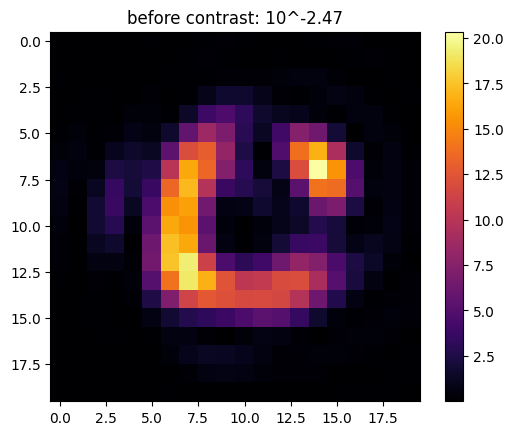

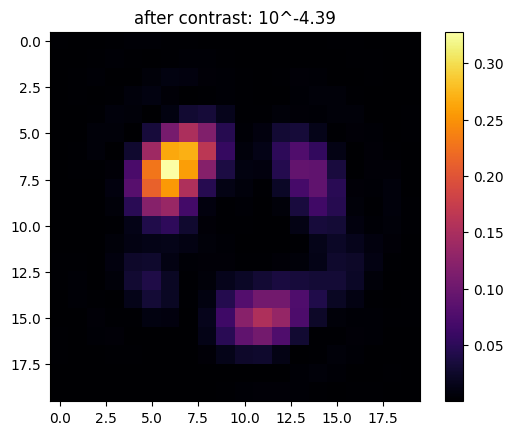

In [40]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        env.deformable_mirror.flatten()
        env.set_random_dm(noise=dm_random_noise)
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)

        img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()

